# TP3 — Regresión con California Housing

## Objetivo
En este trabajo se utiliza el dataset California Housing de scikit-learn para predecir el valor medio de viviendas mediante dos modelos:
- Regresión lineal
- Regresión polinómica de grado 2

Luego se comparan sus métricas y se analiza si existe overfitting.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

## 1. Carga del dataset

In [3]:
california = fetch_california_housing(as_frame=True)

df = california.frame

print("Primeras 5 filas:")
display(df.head())

print("\nInformación general:")
display(df.info())

print("\nEstadísticas descriptivas:")
display(df.describe())

Primeras 5 filas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


None


Estadísticas descriptivas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 2. Exploración del dataset
El dataset contiene variables numéricas relacionadas con características de distritos de California, como ingreso medio, cantidad promedio de habitaciones, población, latitud y longitud. La variable objetivo es `MedHouseVal`, que representa el valor medio de las viviendas.

In [4]:
print("Nombres de las columnas:")
print(df.columns.tolist())

print("\nCantidad de filas y columnas:")
print(df.shape)

print("\nValores nulos por columna:")
print(df.isnull().sum())

Nombres de las columnas:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Cantidad de filas y columnas:
(20640, 9)

Valores nulos por columna:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [5]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Variables predictoras (X):")
display(X.head())

print("Variable objetivo (y):")
display(y.head())

Variables predictoras (X):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Variable objetivo (y):


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

## 3. División en entrenamiento y prueba
Se divide el dataset en 80% para entrenamiento y 20% para prueba.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (16512, 8)
Tamaño de X_test: (4128, 8)
Tamaño de y_train: (16512,)
Tamaño de y_test: (4128,)


## 4. Entrenamiento del modelo de regresión lineal

In [7]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_train_pred_lineal = modelo_lineal.predict(X_train)
y_test_pred_lineal = modelo_lineal.predict(X_test)

In [9]:
mse_train_lineal = mean_squared_error(y_train, y_train_pred_lineal)
mse_test_lineal = mean_squared_error(y_test, y_test_pred_lineal)

r2_train_lineal = r2_score(y_train, y_train_pred_lineal)
r2_test_lineal = r2_score(y_test, y_test_pred_lineal)

print("REGRESIÓN LINEAL")
print(f"MSE train: {mse_train_lineal:.4f}")
print(f"MSE test:  {mse_test_lineal:.4f}")
print(f"R² train:  {r2_train_lineal:.4f}")
print(f"R² test:   {r2_test_lineal:.4f}")

REGRESIÓN LINEAL
MSE train: 0.5179
MSE test:  0.5559
R² train:  0.6126
R² test:   0.5758


## 5. Gráfico de predicciones vs valores reales

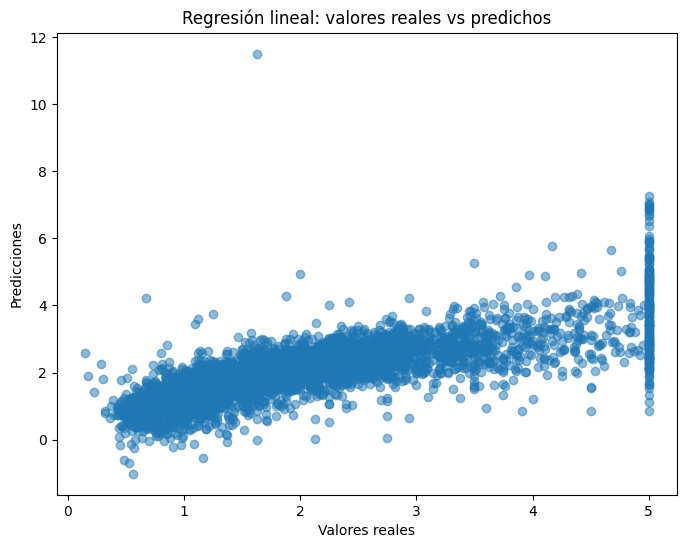

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_lineal, alpha=0.5)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión lineal: valores reales vs predichos")
plt.show()

## 6. Entrenamiento del modelo de regresión polinómica (grado 2)

In [11]:
# Tomamos una muestra más chica para que no se trabe
X_train_small = X_train.sample(5000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

X_test_small = X_test.sample(2000, random_state=42)
y_test_small = y_test.loc[X_test_small.index]

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_small)
X_test_poly = poly.transform(X_test_small)

print("Shape original de X_train:", X_train.shape)
print("Shape reducido de X_train_small:", X_train_small.shape)
print("Shape polinómico de X_train_poly:", X_train_poly.shape)

Shape original de X_train: (16512, 8)
Shape reducido de X_train_small: (5000, 8)
Shape polinómico de X_train_poly: (5000, 44)


In [12]:
modelo_polinomico = LinearRegression()
modelo_polinomico.fit(X_train_poly, y_train_small)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_train_pred_poly = modelo_polinomico.predict(X_train_poly)
y_test_pred_poly = modelo_polinomico.predict(X_test_poly)

In [14]:
mse_train_poly = mean_squared_error(y_train_small, y_train_pred_poly)
mse_test_poly = mean_squared_error(y_test_small, y_test_pred_poly)

r2_train_poly = r2_score(y_train_small, y_train_pred_poly)
r2_test_poly = r2_score(y_test_small, y_test_pred_poly)

print("REGRESIÓN POLINÓMICA (MUESTRA REDUCIDA)")
print(f"MSE train: {mse_train_poly:.4f}")
print(f"MSE test:  {mse_test_poly:.4f}")
print(f"R² train:  {r2_train_poly:.4f}")
print(f"R² test:   {r2_test_poly:.4f}")

REGRESIÓN POLINÓMICA (MUESTRA REDUCIDA)
MSE train: 0.3977
MSE test:  0.4997
R² train:  0.7075
R² test:   0.6104


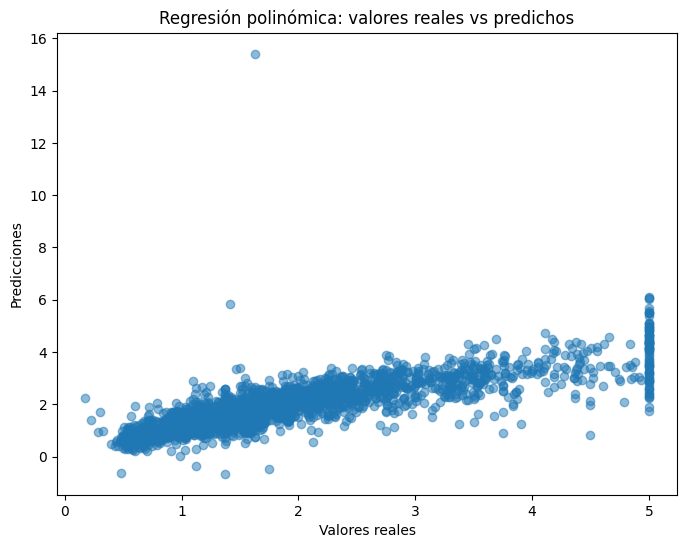

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_small, y_test_pred_poly, alpha=0.5)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión polinómica: valores reales vs predichos")
plt.show()

## 7. Comparación de métricas

In [16]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión lineal", "Regresión polinómica grado 2"],
    "MSE Train": [mse_train_lineal, mse_train_poly],
    "MSE Test": [mse_test_lineal, mse_test_poly],
    "R2 Train": [r2_train_lineal, r2_train_poly],
    "R2 Test": [r2_test_lineal, r2_test_poly]
})

display(resultados)

,Modelo,MSE Train,MSE Test,R2 Train,R2 Test
0,Regresión lineal,0.517933,0.555892,0.612551,0.575788
1,Regresión polinómica grado 2,0.397664,0.499665,0.707517,0.610394


## 8. Importancia aproximada de variables en el modelo lineal

In [17]:
coeficientes = pd.DataFrame({
    "Feature": X.columns,
    "Coeficiente": modelo_lineal.coef_
})

coeficientes["Valor absoluto"] = coeficientes["Coeficiente"].abs()
coeficientes = coeficientes.sort_values(by="Valor absoluto", ascending=False)

display(coeficientes)

,Feature,Coeficiente,Valor absoluto
3,AveBedrms,0.783145,0.783145
0,MedInc,0.448675,0.448675
7,Longitude,-0.433708,0.433708
6,Latitude,-0.419792,0.419792
2,AveRooms,-0.123323,0.123323
1,HouseAge,0.009724,0.009724
5,AveOccup,-0.003526,0.003526
4,Population,-0.000002,0.000002


## Respuestas finales

### ¿Cuál modelo es mejor? ¿Cómo lo determinaron?
El modelo que mostró mejor desempeño fue la **regresión polinómica de grado 2**. Para determinarlo, se compararon principalmente las métricas del conjunto de prueba (**test**), ya que ese conjunto permite evaluar cómo generaliza cada modelo frente a datos no vistos durante el entrenamiento.

Se analizaron dos métricas: el **MSE** y el **R²**. El modelo polinómico obtuvo un **MSE test de 0.499665**, menor que el de la regresión lineal (**0.555892**), lo que indica un menor error de predicción. Además, alcanzó un **R² test de 0.610394**, superior al de la regresión lineal (**0.575788**), lo que significa que explica mejor la variabilidad de los datos.

Por estas razones, se concluye que la **regresión polinómica de grado 2** es el modelo más adecuado entre los dos evaluados.

### ¿Hay señales de overfitting en alguno? ¿Cómo se dan cuenta?
Sí, se observan **señales leves de overfitting en la regresión polinómica de grado 2**. Esto se detecta comparando el rendimiento del modelo en entrenamiento (**train**) y en prueba (**test**).

En el modelo polinómico, el **R²** baja de **0.707517** en train a **0.610394** en test, y el **MSE** aumenta de **0.397664** a **0.499665**. Esto muestra que el modelo rinde mejor sobre los datos de entrenamiento que sobre los datos no vistos, lo cual es una señal de sobreajuste.

Sin embargo, el sobreajuste no parece excesivo, ya que aun con esa diferencia el modelo polinómico sigue obteniendo mejores métricas de prueba que la regresión lineal. Por eso, puede considerarse un caso de **overfitting moderado o leve**, pero no lo suficientemente grave como para descartar el modelo.

### ¿Qué feature tiene más impacto en el precio? ¿Cómo lo averiguaron?
Para estimar qué variable tiene mayor impacto en la predicción del precio de las viviendas, se analizaron los **coeficientes del modelo de regresión lineal**. Estos coeficientes indican cuánto influye cada feature sobre la variable objetivo, y al ordenarlos según su valor absoluto se puede identificar cuál tiene mayor peso relativo dentro del modelo.

A partir de ese análisis, la feature con mayor impacto fue **AveBedrms**, ya que presentó el coeficiente de mayor magnitud en valor absoluto (**0.783145**). Esto permitió concluir que, dentro del modelo lineal, es la variable que más influye aproximadamente en la predicción del precio de las viviendas.